<a href="https://colab.research.google.com/github/Hujjathullah-S-T/Chromatic-9-Graphs/blob/master/GAN_9_working_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ============================================================
# CELL 1 — IMPORTS AND SETUP
# ============================================================

import os
import re
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 41

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [15]:
# ============================================================
# CELL 2 — LOAD DATASET
# ============================================================

DATA_PATH = "Chromatic9_Augmented.txt"


if not os.path.exists(DATA_PATH):

    try:

        from google.colab import files

        print(
            "Please upload Chromatic9_Augmented.txt"
        )

        uploaded = files.upload()

        DATA_PATH = list(
            uploaded.keys()
        )[0]

    except ImportError:

        raise FileNotFoundError(
            f"Could not find {DATA_PATH}"
        )


with open(
    DATA_PATH,
    "r",
    encoding="utf-8",
    errors="replace"
) as f:

    raw_text = f.read()


print(
    f"Loaded {len(raw_text):,} characters "
    f"from {DATA_PATH}"
)

Loaded 372,125 characters from Chromatic9_Augmented.txt


In [16]:
# ============================================================
# CELL 3 — PARSE DATASET
# ============================================================

def parse_dataset(text):

    """
    Parse Chromatic9_Augmented.txt.

    Graph format:

        ID19-14.69.1:
        1 - 3,4,8,5
        2 - 1,4,7
        ...

    Returns:

        [
            {
                "id": graph_id,
                "n_nodes": n,
                "edges": set(...)
            },
            ...
        ]
    """

    lines = text.splitlines()

    blocks = []

    current_id = None
    current_lines = []


    # --------------------------------------------------------
    # Split file into graph blocks
    # --------------------------------------------------------

    for line in lines:

        s = line.strip()

        if not s:
            continue


        if s.startswith("ID"):

            if current_id is not None:

                blocks.append(
                    (
                        current_id,
                        current_lines
                    )
                )

            current_id = s.rstrip(":").strip()

            current_lines = []


        else:

            current_lines.append(s)


    # Last graph

    if current_id is not None:

        blocks.append(
            (
                current_id,
                current_lines
            )
        )


    # --------------------------------------------------------
    # Node line pattern
    # --------------------------------------------------------

    node_line_pattern = re.compile(
        r"^(\d+)\s*[-\u2013]\s*(.+?);?\s*$"
    )


    graphs = []


    # --------------------------------------------------------
    # Parse each graph
    # --------------------------------------------------------

    for graph_id, block_lines in blocks:

        adjacency = {}


        for line in block_lines:

            match = node_line_pattern.match(
                line
            )

            if not match:
                continue


            node = int(
                match.group(1)
            )


            # IMPORTANT:
            # Correct regex is r"\d+"
            #
            # NOT:
            # r"\\d+"

            neighbor_numbers = re.findall(
                r"\d+",
                match.group(2)
            )


            neighbors = [
                int(x)
                for x in neighbor_numbers
            ]


            adjacency[node] = set(
                neighbors
            )


        if not adjacency:
            continue


        nodes = sorted(
            adjacency.keys()
        )


        n_nodes = len(nodes)


        # ----------------------------------------------------
        # Map original node IDs to 0...n-1
        # ----------------------------------------------------

        index = {
            node: i
            for i, node in enumerate(nodes)
        }


        edges = set()


        for u in adjacency:

            for v in adjacency[u]:

                if v not in index:
                    continue


                a = index[u]
                b = index[v]


                # No self-loops

                if a == b:
                    continue


                edges.add(
                    (
                        min(a, b),
                        max(a, b)
                    )
                )


        graphs.append(
            {
                "id": graph_id,
                "n_nodes": n_nodes,
                "edges": edges
            }
        )


    return graphs


# ------------------------------------------------------------
# Parse
# ------------------------------------------------------------

parsed_graphs = parse_dataset(
    raw_text
)


print()
print("=" * 70)
print("DATASET PARSING")
print("=" * 70)

print(
    "Parsed graphs:",
    len(parsed_graphs)
)


node_distribution = Counter(
    g["n_nodes"]
    for g in parsed_graphs
)


print(
    "Node-count distribution:",
    dict(
        sorted(
            node_distribution.items()
        )
    )
)


MAX_NODES = max(
    g["n_nodes"]
    for g in parsed_graphs
)


print(
    "MAX_NODES:",
    MAX_NODES
)


DATASET PARSING
Parsed graphs: 840
Node-count distribution: {12: 42, 13: 210, 14: 357, 15: 84, 16: 147}
MAX_NODES: 16


In [17]:
# ============================================================
# CELL 4 — DATASET SANITY CHECK
# ============================================================

edge_counts = [

    len(g["edges"])

    for g in parsed_graphs

]


print()
print("=" * 70)
print("DATASET SANITY CHECK")
print("=" * 70)


print(
    "Minimum edges:",
    min(edge_counts)
)


print(
    "Maximum edges:",
    max(edge_counts)
)


print(
    "Average edges:",
    np.mean(edge_counts)
)


if max(edge_counts) == 0:

    raise RuntimeError(
        """
ERROR:

All graphs contain zero edges.

The dataset parser is not working correctly.
Check Cell 3.
"""
    )


print()
print(
    "SUCCESS: parsed graphs contain edges."
)


DATASET SANITY CHECK
Minimum edges: 56
Maximum edges: 84
Average edges: 70.55

SUCCESS: parsed graphs contain edges.


In [18]:
# ============================================================
# CELL 5 — EXACT CHROMATIC NUMBER
# ============================================================

def exact_chromatic_number(
    A,
    time_limit=10.0
):

    """
    Exact chromatic number using
    backtracking with degree ordering.

    Returns:

        (chromatic_number, coloring)

    If time limit is exceeded:

        (None, None)
    """

    A = np.asarray(
        A
    ).astype(bool)


    n = A.shape[0]


    if n == 0:

        return 0, []


    start_time = time.time()


    # --------------------------------------------------------
    # Vertex degrees
    # --------------------------------------------------------

    degrees = A.sum(
        axis=1
    ).tolist()


    # --------------------------------------------------------
    # Highest degree first
    # --------------------------------------------------------

    order = sorted(
        range(n),
        key=lambda x: -degrees[x]
    )


    # --------------------------------------------------------
    # Greedy clique lower bound
    # --------------------------------------------------------

    clique = []


    for v in order:

        if all(
            A[v, u]
            for u in clique
        ):

            clique.append(v)


    lower_bound = max(
        1,
        len(clique)
    )


    # --------------------------------------------------------
    # Neighbor sets
    # --------------------------------------------------------

    neighbors = [

        set(
            np.nonzero(
                A[i]
            )[0].tolist()
        )

        for i in range(n)

    ]


    # --------------------------------------------------------
    # k-colorability test
    # --------------------------------------------------------

    def can_color(k):

        colors = [-1] * n


        def backtrack(position):

            if (
                time.time()
                - start_time
                > time_limit
            ):

                return None


            if position == n:

                return True


            v = order[position]


            used_colors = {

                colors[u]

                for u in neighbors[v]

                if colors[u] != -1

            }


            for color in range(k):

                if color in used_colors:
                    continue


                colors[v] = color


                result = backtrack(
                    position + 1
                )


                if result is True:

                    return True


                if result is None:

                    return None


                colors[v] = -1


            colors[v] = -1

            return False


        result = backtrack(0)


        if result is True:

            return True, colors[:]


        if result is None:

            return None, None


        return False, None


    # --------------------------------------------------------
    # Search for minimum k
    # --------------------------------------------------------

    for k in range(
        lower_bound,
        n + 1
    ):

        success, coloring = can_color(k)


        if success is None:

            return None, None


        if success:

            return k, coloring


    return n, list(range(n))

In [19]:
# ============================================================
# CELL 6 — CHROMATIC NUMBER SELF TEST
# ============================================================

def chromatic_self_test():

    rng = random.Random(0)

    n = 10


    # --------------------------------------------------------
    # Complete graph K10
    # --------------------------------------------------------

    A = np.ones(
        (n, n),
        dtype=np.int64
    )


    np.fill_diagonal(
        A,
        0
    )


    chi, coloring = (
        exact_chromatic_number(
            A,
            time_limit=10
        )
    )


    assert chi == 10


    # --------------------------------------------------------
    # Empty graph
    # --------------------------------------------------------

    B = np.zeros(
        (n, n),
        dtype=np.int64
    )


    chi2, coloring2 = (
        exact_chromatic_number(
            B,
            time_limit=10
        )
    )


    assert chi2 == 1


    print(
        "Self-test passed."
    )

    print(
        "K10 chromatic number:",
        chi
    )

    print(
        "Empty graph chromatic number:",
        chi2
    )


chromatic_self_test()

Self-test passed.
K10 chromatic number: 10
Empty graph chromatic number: 1


In [20]:
# ============================================================
# CELL 7 — INPUT DATASET VERIFICATION
# ============================================================
#
# IMPORTANT:
# The input dataset is already known to contain
# ONLY graphs with chromatic number χ = 9.
#
# Therefore, we do NOT run the expensive exact
# chromatic-number solver on all 840 input graphs.
#
# The exact solver will only be used later to verify
# GENERATED graphs.
# ============================================================


print()
print("=" * 70)
print("INPUT DATASET")
print("=" * 70)


print(
    "Total input graphs:",
    len(parsed_graphs)
)


print(
    "Known chromatic number:",
    "χ = 9"
)


print(
    "Dataset status:",
    "ALL INPUT GRAPHS ARE 9-CHROMATIC"
)


# ------------------------------------------------------------
# Basic structural checks only
# ------------------------------------------------------------

node_counts = [
    g["n_nodes"]
    for g in parsed_graphs
]


edge_counts = [
    len(g["edges"])
    for g in parsed_graphs
]


print()
print(
    "Node-count distribution:"
)


print(
    dict(
        sorted(
            Counter(
                node_counts
            ).items()
        )
    )
)


print()
print(
    "Edge-count range:"
)


print(
    "Minimum:",
    min(edge_counts)
)


print(
    "Maximum:",
    max(edge_counts)
)


print()
print("=" * 70)
print("INPUT DATASET READY FOR TRAINING")
print("=" * 70)


print(
    "Graphs used for GAN training:",
    len(parsed_graphs)
)


print(
    "Target chromatic number:",
    9
)


INPUT DATASET
Total input graphs: 840
Known chromatic number: χ = 9
Dataset status: ALL INPUT GRAPHS ARE 9-CHROMATIC

Node-count distribution:
{12: 42, 13: 210, 14: 357, 15: 84, 16: 147}

Edge-count range:
Minimum: 56
Maximum: 84

INPUT DATASET READY FOR TRAINING
Graphs used for GAN training: 840
Target chromatic number: 9


In [21]:
# ============================================================
# CELL 8 — GRAPH PREPROCESSING
# ============================================================

triu_i, triu_j = np.triu_indices(
    MAX_NODES,
    k=1
)


EDGE_DIM = len(
    triu_i
)


print(
    "MAX_NODES:",
    MAX_NODES
)


print(
    "EDGE_DIM:",
    EDGE_DIM
)


def adj_to_edge_vector(A):

    return A[
        triu_i,
        triu_j
    ].astype(
        np.float32
    )


def edge_vector_to_adj(
    vector
):

    A = np.zeros(
        (
            MAX_NODES,
            MAX_NODES
        ),
        dtype=np.int64
    )


    vector = np.asarray(
        vector
    ).astype(
        np.int64
    )


    A[
        triu_i,
        triu_j
    ] = vector


    A[
        triu_j,
        triu_i
    ] = vector


    np.fill_diagonal(
        A,
        0
    )


    return A


# ------------------------------------------------------------
# Convert all graphs
# ------------------------------------------------------------

all_adj = [

    edges_to_adj(
        g["edges"],
        g["n_nodes"],
        MAX_NODES
    )

    for g in parsed_graphs

]


all_edge_vectors = np.stack(

    [
        adj_to_edge_vector(A)

        for A in all_adj

    ]

)


print(
    "Dataset tensor shape:",
    all_edge_vectors.shape
)

MAX_NODES: 16
EDGE_DIM: 120
Dataset tensor shape: (840, 120)


In [22]:
# ============================================================
# CELL 9 — TRAIN / TEST SPLIT
# ============================================================

indices = np.arange(
    len(all_edge_vectors)
)


np.random.shuffle(
    indices
)


split = int(
    0.8 * len(indices)
)


train_idx = indices[
    :split
]


test_idx = indices[
    split:
]


train_vectors = (
    all_edge_vectors[
        train_idx
    ]
)


test_vectors = (
    all_edge_vectors[
        test_idx
    ]
)


print(
    "Training graphs:",
    len(train_vectors)
)


print(
    "Test graphs:",
    len(test_vectors)
)


# ------------------------------------------------------------
# Dataset class
# ------------------------------------------------------------

class GraphEdgeDataset(
    Dataset
):

    def __init__(
        self,
        edge_vectors
    ):

        self.data = torch.tensor(
            edge_vectors,
            dtype=torch.float32
        )


    def __len__(self):

        return len(
            self.data
        )


    def __getitem__(
        self,
        index
    ):

        return self.data[
            index
        ]


BATCH_SIZE = 32


train_dataset = GraphEdgeDataset(
    train_vectors
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)


print(
    "Training batches:",
    len(train_loader)
)

Training graphs: 672
Test graphs: 168
Training batches: 21


In [23]:
# ============================================================
# CELL 10 — GENERATOR
# ============================================================

class Generator(
    nn.Module
):

    def __init__(
        self,
        latent_dim,
        edge_dim,
        hidden=256
    ):

        super().__init__()


        self.net = nn.Sequential(

            nn.Linear(
                latent_dim,
                hidden
            ),

            nn.BatchNorm1d(
                hidden
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Linear(
                hidden,
                hidden * 2
            ),

            nn.BatchNorm1d(
                hidden * 2
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Linear(
                hidden * 2,
                hidden
            ),

            nn.BatchNorm1d(
                hidden
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Linear(
                hidden,
                edge_dim
            ),

            nn.Sigmoid()

        )


    def forward(
        self,
        z
    ):

        return self.net(z)

In [24]:
# ============================================================
# CELL 11 — DISCRIMINATOR
# ============================================================

class Discriminator(
    nn.Module
):

    def __init__(
        self,
        edge_dim,
        hidden=256
    ):

        super().__init__()


        self.net = nn.Sequential(

            nn.Linear(
                edge_dim,
                hidden * 2
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Dropout(
                0.3
            ),


            nn.Linear(
                hidden * 2,
                hidden
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),

            nn.Dropout(
                0.3
            ),


            nn.Linear(
                hidden,
                hidden // 2
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.Linear(
                hidden // 2,
                1
            ),

            nn.Sigmoid()

        )


    def forward(
        self,
        x
    ):

        return self.net(x)

In [25]:
# ============================================================
# CELL 12 — INITIALIZE GAN
# ============================================================

LATENT_DIM = 100

N_EPOCHS = 400

LR = 2e-4

BETA1 = 0.5

BETA2 = 0.999

LABEL_SMOOTH_REAL = 0.9


generator = Generator(
    LATENT_DIM,
    EDGE_DIM
).to(device)


discriminator = Discriminator(
    EDGE_DIM
).to(device)


criterion = nn.BCELoss()


opt_G = optim.Adam(
    generator.parameters(),
    lr=LR,
    betas=(
        BETA1,
        BETA2
    )
)


opt_D = optim.Adam(
    discriminator.parameters(),
    lr=LR,
    betas=(
        BETA1,
        BETA2
    )
)


print(
    "Generator initialized."
)


print(
    "Discriminator initialized."
)


print(
    "Latent dimension:",
    LATENT_DIM
)


print(
    "Edge dimension:",
    EDGE_DIM
)

Generator initialized.
Discriminator initialized.
Latent dimension: 100
Edge dimension: 120


In [26]:
# ============================================================
# CELL 13 — TRAIN GAN
# ============================================================

g_losses = []

d_losses = []


for epoch in range(
    1,
    N_EPOCHS + 1
):

    epoch_g_loss = 0.0

    epoch_d_loss = 0.0

    n_batches = 0


    for real_batch in train_loader:

        real_batch = real_batch.to(
            device
        )


        bsz = real_batch.size(0)


        # ====================================================
        # DISCRIMINATOR
        # ====================================================

        real_labels = torch.full(
            (bsz, 1),
            LABEL_SMOOTH_REAL,
            device=device
        )


        fake_labels = torch.zeros(
            (bsz, 1),
            device=device
        )


        opt_D.zero_grad()


        # Real

        pred_real = discriminator(
            real_batch
        )


        loss_d_real = criterion(
            pred_real,
            real_labels
        )


        # Fake

        z = torch.randn(
            bsz,
            LATENT_DIM,
            device=device
        )


        fake_batch = generator(
            z
        )


        pred_fake = discriminator(
            fake_batch.detach()
        )


        loss_d_fake = criterion(
            pred_fake,
            fake_labels
        )


        loss_d = (
            loss_d_real
            + loss_d_fake
        )


        loss_d.backward()

        opt_D.step()


        # ====================================================
        # GENERATOR
        # ====================================================

        opt_G.zero_grad()


        pred_fake_for_g = discriminator(
            fake_batch
        )


        generator_labels = torch.ones(
            (bsz, 1),
            device=device
        )


        loss_g = criterion(
            pred_fake_for_g,
            generator_labels
        )


        loss_g.backward()

        opt_G.step()


        epoch_g_loss += (
            loss_g.item()
        )


        epoch_d_loss += (
            loss_d.item()
        )


        n_batches += 1


    epoch_g_loss /= n_batches

    epoch_d_loss /= n_batches


    g_losses.append(
        epoch_g_loss
    )


    d_losses.append(
        epoch_d_loss
    )


    if (
        epoch == 1
        or epoch % 25 == 0
    ):

        print(
            f"Epoch [{epoch:4d}/{N_EPOCHS}] "
            f"D_loss: {epoch_d_loss:.4f} "
            f"G_loss: {epoch_g_loss:.4f}"
        )


print()
print(
    "Training complete."
)


print(
    "Final Generator loss:",
    g_losses[-1]
)


print(
    "Final Discriminator loss:",
    d_losses[-1]
)

Epoch [   1/400] D_loss: 1.2818 G_loss: 0.7656
Epoch [  25/400] D_loss: 0.5326 G_loss: 3.3363
Epoch [  50/400] D_loss: 0.5039 G_loss: 3.8911
Epoch [  75/400] D_loss: 0.5462 G_loss: 3.9690
Epoch [ 100/400] D_loss: 0.4929 G_loss: 4.3891
Epoch [ 125/400] D_loss: 0.5160 G_loss: 4.1827
Epoch [ 150/400] D_loss: 0.5644 G_loss: 3.8714
Epoch [ 175/400] D_loss: 0.5152 G_loss: 4.0877
Epoch [ 200/400] D_loss: 0.5555 G_loss: 3.9368
Epoch [ 225/400] D_loss: 0.5519 G_loss: 3.7611
Epoch [ 250/400] D_loss: 0.5795 G_loss: 3.7611
Epoch [ 275/400] D_loss: 0.5596 G_loss: 3.8400
Epoch [ 300/400] D_loss: 0.5887 G_loss: 3.8783
Epoch [ 325/400] D_loss: 0.6084 G_loss: 3.7196
Epoch [ 350/400] D_loss: 0.5392 G_loss: 4.1399
Epoch [ 375/400] D_loss: 0.5539 G_loss: 3.8261
Epoch [ 400/400] D_loss: 0.5986 G_loss: 3.7914

Training complete.
Final Generator loss: 3.7913772832779657
Final Discriminator loss: 0.5986179283687046


In [27]:
# ============================================================
# CELL 14 — SAVE MODELS
# ============================================================

MODEL_DIR = "saved_models"


os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


generator_path = os.path.join(
    MODEL_DIR,
    "generator.pt"
)


discriminator_path = os.path.join(
    MODEL_DIR,
    "discriminator.pt"
)


torch.save(
    generator.state_dict(),
    generator_path
)


torch.save(
    discriminator.state_dict(),
    discriminator_path
)


print(
    "Generator saved to:",
    generator_path
)


print(
    "Discriminator saved to:",
    discriminator_path
)

Generator saved to: saved_models/generator.pt
Discriminator saved to: saved_models/discriminator.pt


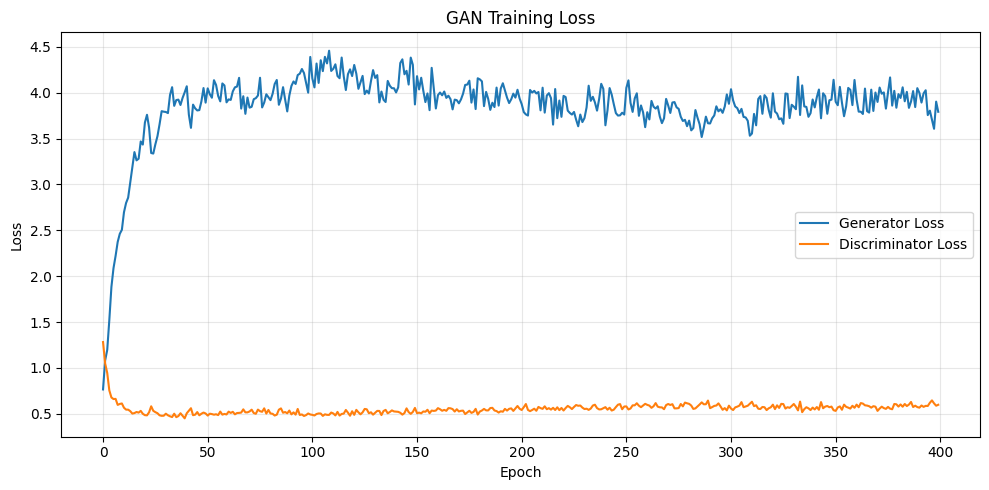

In [28]:
# ============================================================
# CELL 15 — PLOT GAN LOSSES
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    g_losses,
    label="Generator Loss"
)


plt.plot(
    d_losses,
    label="Discriminator Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "GAN Training Loss"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "gan_losses.png",
    dpi=150
)


plt.show()

In [29]:
# ============================================================
# CELL 16 — GENERATION SETTINGS
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
#
# This is the number of CANDIDATE graphs generated.
#
# It is NOT the number of χ=9 graphs.
#
# The final number of χ=9 graphs can be:
#
#     higher than 45
#     lower than 45
#     exactly 45
#     or even 0
#
# ------------------------------------------------------------

N_GENERATE = 1000


# Probability -> binary edge threshold

THRESHOLD = 0.5


# Exact chromatic number time limit

CHROMATIC_TIME_LIMIT = 10.0


print(
    "Candidate graphs to generate:",
    N_GENERATE
)


print(
    "Binary threshold:",
    THRESHOLD
)


print(
    "Chromatic-number time limit:",
    CHROMATIC_TIME_LIMIT
)

Candidate graphs to generate: 1000
Binary threshold: 0.5
Chromatic-number time limit: 10.0


In [30]:
# ============================================================
# CELL 17 — GENERATE CANDIDATE GRAPHS
# ============================================================

generator.eval()


all_generated_results = []


chromatic_numbers = []


print()
print("=" * 70)
print("GENERATING CANDIDATE GRAPHS")
print("=" * 70)


generated_count = 0


while generated_count < N_GENERATE:

    batch_size = min(
        500,
        N_GENERATE - generated_count
    )


    # --------------------------------------------------------
    # Random latent vectors
    # --------------------------------------------------------

    z = torch.randn(
        batch_size,
        LATENT_DIM,
        device=device
    )


    # --------------------------------------------------------
    # Generate graphs
    # --------------------------------------------------------

    with torch.no_grad():

        soft_edges = generator(
            z
        ).cpu().numpy()


    # --------------------------------------------------------
    # Process each graph
    # --------------------------------------------------------

    for vector in soft_edges:

        current_id = generated_count


        # ----------------------------------------------------
        # Convert probabilities to 0/1 edges
        # ----------------------------------------------------

        binary_vector = (
            vector >= THRESHOLD
        ).astype(
            np.int64
        )


        A = edge_vector_to_adj(
            binary_vector
        )


        # ----------------------------------------------------
        # Remove isolated nodes
        # ----------------------------------------------------

        degrees = A.sum(
            axis=1
        )


        active_nodes = np.where(
            degrees > 0
        )[0]


        # Empty graph

        if len(active_nodes) == 0:

            chromatic_numbers.append(
                1
            )

            generated_count += 1

            continue


        B = A[
            np.ix_(
                active_nodes,
                active_nodes
            )
        ]


        n_nodes = B.shape[0]


        # ----------------------------------------------------
        # Keep original graph-size range
        # ----------------------------------------------------

        if (
            n_nodes < 12
            or n_nodes > 16
        ):

            chromatic_numbers.append(
                None
            )

            generated_count += 1

            continue


        # ----------------------------------------------------
        # EXACT CHROMATIC NUMBER
        # ----------------------------------------------------

        chi, coloring = (
            exact_chromatic_number(
                B,
                time_limit=
                    CHROMATIC_TIME_LIMIT
            )
        )


        chromatic_numbers.append(
            chi
        )


        # ----------------------------------------------------
        # Only keep χ=9
        # ----------------------------------------------------

        if chi != 9:

            generated_count += 1

            continue


        # ----------------------------------------------------
        # Count edges
        # ----------------------------------------------------

        edge_pairs = []


        for i in range(
            n_nodes
        ):

            for j in range(
                i + 1,
                n_nodes
            ):

                if B[i, j] == 1:

                    edge_pairs.append(
                        (
                            i,
                            j
                        )
                    )


        n_edges = len(
            edge_pairs
        )


        # ----------------------------------------------------
        # Edge list
        # ----------------------------------------------------

        edge_list = ";".join(

            f"{u}-{v}"

            for u, v in edge_pairs

        )


        # ----------------------------------------------------
        # Padded adjacency matrix
        # ----------------------------------------------------

        final_A = np.zeros(
            (
                MAX_NODES,
                MAX_NODES
            ),
            dtype=np.int64
        )


        final_A[
            :n_nodes,
            :n_nodes
        ] = B


        # ----------------------------------------------------
        # Upper triangular adjacency
        # ----------------------------------------------------

        upper = final_A[
            triu_i,
            triu_j
        ]


        adjacency_upper_triangular = ",".join(

            str(int(x))

            for x in upper

        )


        # ----------------------------------------------------
        # Store χ=9 graph
        # ----------------------------------------------------

        all_generated_results.append(

            {
                "generated_id":
                    current_id,

                "n_nodes":
                    n_nodes,

                "n_edges":
                    n_edges,

                "chromatic_number":
                    chi,

                "edge_list":
                    edge_list,

                "adjacency_upper_triangular":
                    adjacency_upper_triangular

            }

        )


        print(
            f"Candidate "
            f"{current_id + 1}/"
            f"{N_GENERATE} "
            f"-> χ={chi} "
            f"-> KEPT"
        )


        generated_count += 1


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        generated_count % 500 == 0
        or generated_count == N_GENERATE
    ):

        print(
            f"Progress: "
            f"{generated_count}/"
            f"{N_GENERATE} candidates processed | "
            f"χ=9 graphs kept: "
            f"{len(all_generated_results)}"
        )


print()
print("=" * 70)
print("GENERATION COMPLETE")
print("=" * 70)


print(
    "Total candidates generated:",
    N_GENERATE
)


print(
    "Total χ=9 graphs found:",
    len(all_generated_results)
)


print(
    "Total graphs rejected:",
    N_GENERATE
    - len(all_generated_results)
)


print()
print(
    "Chromatic-number distribution:"
)


distribution = Counter(
    x
    for x in chromatic_numbers
    if x is not None
)


print(
    dict(
        sorted(
            distribution.items()
        )
    )
)


GENERATING CANDIDATE GRAPHS
Candidate 18/1000 -> χ=9 -> KEPT
Candidate 20/1000 -> χ=9 -> KEPT
Candidate 40/1000 -> χ=9 -> KEPT
Candidate 58/1000 -> χ=9 -> KEPT
Candidate 61/1000 -> χ=9 -> KEPT
Candidate 97/1000 -> χ=9 -> KEPT
Candidate 100/1000 -> χ=9 -> KEPT
Candidate 109/1000 -> χ=9 -> KEPT
Candidate 111/1000 -> χ=9 -> KEPT
Candidate 119/1000 -> χ=9 -> KEPT
Candidate 128/1000 -> χ=9 -> KEPT
Candidate 140/1000 -> χ=9 -> KEPT
Candidate 146/1000 -> χ=9 -> KEPT
Candidate 147/1000 -> χ=9 -> KEPT
Candidate 162/1000 -> χ=9 -> KEPT
Candidate 164/1000 -> χ=9 -> KEPT
Candidate 167/1000 -> χ=9 -> KEPT
Candidate 183/1000 -> χ=9 -> KEPT
Candidate 206/1000 -> χ=9 -> KEPT
Candidate 210/1000 -> χ=9 -> KEPT
Candidate 221/1000 -> χ=9 -> KEPT
Candidate 230/1000 -> χ=9 -> KEPT
Candidate 232/1000 -> χ=9 -> KEPT
Candidate 247/1000 -> χ=9 -> KEPT
Candidate 269/1000 -> χ=9 -> KEPT
Candidate 274/1000 -> χ=9 -> KEPT
Candidate 283/1000 -> χ=9 -> KEPT
Candidate 295/1000 -> χ=9 -> KEPT
Candidate 303/1000 -> χ=9

In [31]:
# ============================================================
# CELL 18 — FINAL EXACT VERIFICATION
# ============================================================

print()
print("=" * 70)
print("FINAL VERIFICATION")
print("=" * 70)


verified_results = []


for result in all_generated_results:

    n = result[
        "n_nodes"
    ]


    # --------------------------------------------------------
    # Reconstruct upper-triangular vector
    # --------------------------------------------------------

    values = np.array(

        [
            int(x)

            for x in result[
                "adjacency_upper_triangular"
            ].split(",")

        ],

        dtype=np.int64
    )


    # --------------------------------------------------------
    # Reconstruct adjacency
    # --------------------------------------------------------

    A = edge_vector_to_adj(
        values
    )


    # Only actual nodes

    B = A[
        :n,
        :n
    ]


    # --------------------------------------------------------
    # Calculate exact chromatic number again
    # --------------------------------------------------------

    chi, coloring = (
        exact_chromatic_number(
            B,
            time_limit=
                CHROMATIC_TIME_LIMIT
        )
    )


    # --------------------------------------------------------
    # Keep if still χ=9
    # --------------------------------------------------------

    if chi == 9:

        verified_results.append(
            result
        )


    else:

        print(
            "Graph failed verification:",
            result[
                "generated_id"
            ],
            "χ =",
            chi
        )


all_generated_results = verified_results


print()
print(
    "Final verified χ=9 graphs:",
    len(all_generated_results)
)


if len(all_generated_results) == 0:

    print(
        "No χ=9 graphs were found."
    )

else:

    print(
        "All retained graphs verified as χ=9."
    )


FINAL VERIFICATION

Final verified χ=9 graphs: 102
All retained graphs verified as χ=9.


In [32]:
# ============================================================
# CELL 19 — CREATE OUTPUT CSV
# ============================================================

OUTPUT_CSV = (
    "generated_9_chromatic_graphs.csv"
)


OUTPUT_COLUMNS = [

    "generated_id",

    "n_nodes",

    "n_edges",

    "chromatic_number",

    "edge_list",

    "adjacency_upper_triangular"

]


output_df = pd.DataFrame(
    all_generated_results,
    columns=OUTPUT_COLUMNS
)


output_df.to_csv(
    OUTPUT_CSV,
    index=False
)


print()
print("=" * 70)
print("CSV CREATED")
print("=" * 70)


print(
    "File:",
    OUTPUT_CSV
)


print(
    "Number of χ=9 graphs:",
    len(output_df)
)


print(
    "Columns:",
    list(output_df.columns)
)


display(
    output_df.head()
)


CSV CREATED
File: generated_9_chromatic_graphs.csv
Number of χ=9 graphs: 102
Columns: ['generated_id', 'n_nodes', 'n_edges', 'chromatic_number', 'edge_list', 'adjacency_upper_triangular']


,generated_id,n_nodes,n_edges,chromatic_number,edge_list,adjacency_upper_triangular
0,17,13,70,9,0-1;0-2;0-3;0-4;0-5;0-6;0-7;0-8;0-9;0-10;0-12;...,"1,1,1,1,1,1,1,1,1,1,0,1,0,0,0,1,1,1,1,1,1,1,1,..."
1,19,13,62,9,0-1;0-2;0-5;0-6;0-7;0-8;0-11;1-2;1-3;1-5;1-6;1...,"1,1,0,0,1,1,1,1,0,0,1,0,0,0,0,1,1,0,1,1,1,1,1,..."
2,39,13,63,9,0-1;0-2;0-7;0-9;0-10;0-11;1-2;1-3;1-5;1-6;1-7;...,"1,1,0,0,0,0,1,0,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,..."
3,57,14,68,9,0-1;0-2;0-5;0-6;0-7;0-8;0-9;0-10;0-11;0-13;1-2...,"1,1,0,0,1,1,1,1,1,1,1,0,1,0,0,1,1,0,1,1,1,0,1,..."
4,60,13,64,9,0-1;0-2;0-4;0-5;0-6;0-7;0-8;0-9;0-10;0-11;0-12...,"1,1,0,1,1,1,1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,..."


In [33]:
# ============================================================
# CELL 20 — VALIDATE OUTPUT CSV
# ============================================================

check_df = pd.read_csv(
    OUTPUT_CSV
)


print()
print("=" * 70)
print("OUTPUT CSV VALIDATION")
print("=" * 70)


print(
    "Rows:",
    len(check_df)
)


print(
    "Columns:",
    len(check_df.columns)
)


print()
print(
    "Column names:"
)


for column in check_df.columns:

    print(
        " -",
        column
    )


print()
print(
    "Chromatic-number distribution:"
)


print(
    check_df[
        "chromatic_number"
    ].value_counts().to_dict()
)


print()
print(
    "Node-count distribution:"
)


print(
    check_df[
        "n_nodes"
    ].value_counts().sort_index().to_dict()
)


print()
print(
    "First 5 rows:"
)


display(
    check_df.head()
)


# ------------------------------------------------------------
# Verify columns
# ------------------------------------------------------------

required_columns = [

    "generated_id",

    "n_nodes",

    "n_edges",

    "chromatic_number",

    "edge_list",

    "adjacency_upper_triangular"

]


for column in required_columns:

    assert column in check_df.columns


# ------------------------------------------------------------
# Verify every exported graph is χ=9
# ------------------------------------------------------------

if len(check_df) > 0:

    assert (
        check_df[
            "chromatic_number"
        ] == 9
    ).all()


print()
print(
    "SUCCESS:"
)


if len(check_df) > 0:

    print(
        "Every exported graph has "
        "chromatic number = 9."
    )

else:

    print(
        "No χ=9 graphs were found "
        "among the generated candidates."
    )


OUTPUT CSV VALIDATION
Rows: 102
Columns: 6

Column names:
 - generated_id
 - n_nodes
 - n_edges
 - chromatic_number
 - edge_list
 - adjacency_upper_triangular

Chromatic-number distribution:
{9: 102}

Node-count distribution:
{12: 4, 13: 61, 14: 37}

First 5 rows:


,generated_id,n_nodes,n_edges,chromatic_number,edge_list,adjacency_upper_triangular
0,17,13,70,9,0-1;0-2;0-3;0-4;0-5;0-6;0-7;0-8;0-9;0-10;0-12;...,"1,1,1,1,1,1,1,1,1,1,0,1,0,0,0,1,1,1,1,1,1,1,1,..."
1,19,13,62,9,0-1;0-2;0-5;0-6;0-7;0-8;0-11;1-2;1-3;1-5;1-6;1...,"1,1,0,0,1,1,1,1,0,0,1,0,0,0,0,1,1,0,1,1,1,1,1,..."
2,39,13,63,9,0-1;0-2;0-7;0-9;0-10;0-11;1-2;1-3;1-5;1-6;1-7;...,"1,1,0,0,0,0,1,0,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,..."
3,57,14,68,9,0-1;0-2;0-5;0-6;0-7;0-8;0-9;0-10;0-11;0-13;1-2...,"1,1,0,0,1,1,1,1,1,1,1,0,1,0,0,1,1,0,1,1,1,0,1,..."
4,60,13,64,9,0-1;0-2;0-4;0-5;0-6;0-7;0-8;0-9;0-10;0-11;0-12...,"1,1,0,1,1,1,1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,..."



SUCCESS:
Every exported graph has chromatic number = 9.


In [34]:
# ============================================================
# CELL 21 — DOWNLOAD CSV
# ============================================================

try:

    from google.colab import files

    files.download(
        OUTPUT_CSV
    )

except Exception:

    print(
        "CSV saved at:",
        OUTPUT_CSV
    )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>